# Q2: Zonal day-ahead spreads

**Question.** The panel holds three zonal day-ahead prices for the same delivery
hour: DE/LU (`da_price`), Danish DK1 (`id3_price`) and Belgium
(`id_continuous`). Column names are historical; the map is in `FINDINGS.md`.
Under market coupling the zones clear at identical prices unless an
interconnector congests, so the questions are: how often are the prices
literally identical, are the spreads stationary, how fast do they close, and
does their dispersion widen with the German forecast-error regime?

**Method.** ADF and KPSS per series, Engle-Granger on the pairs, Johansen rank,
a VECM for adjustment speeds, the spread half-life from a closed-form AR(1),
and regime-conditional spread sigma. The formal tests run on daily means of the
most recent three years; only the half-life uses the full hourly sample.


In [1]:
# Common imports, shared by all three notebooks.
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
FIG = RESULTS / 'figures'
TAB = RESULTS / 'tables'

with open(RESULTS / 'summary.json') as f:
    SUMMARY = json.load(f)

WINDOW = SUMMARY['window']
print(f"Sample window: {WINDOW['start']} → {WINDOW['end']}")


Sample window: 2018-10-01 → 2026-05-04


## 1.  Spread descriptives

In [2]:
df = pd.read_csv(TAB / 'q2_spread_descriptives.csv', index_col=0)
display(df)

,count,mean,std,min,25%,50%,75%,max
da_id_spread,66529.0,-1.282953,25.105321,-432.32,-1.65,0.0,2.92,474.11
id1_spread,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id3_spread,66529.0,-8.524590,33.682050,-442.37,-11.63,0.0,1.58,511.74


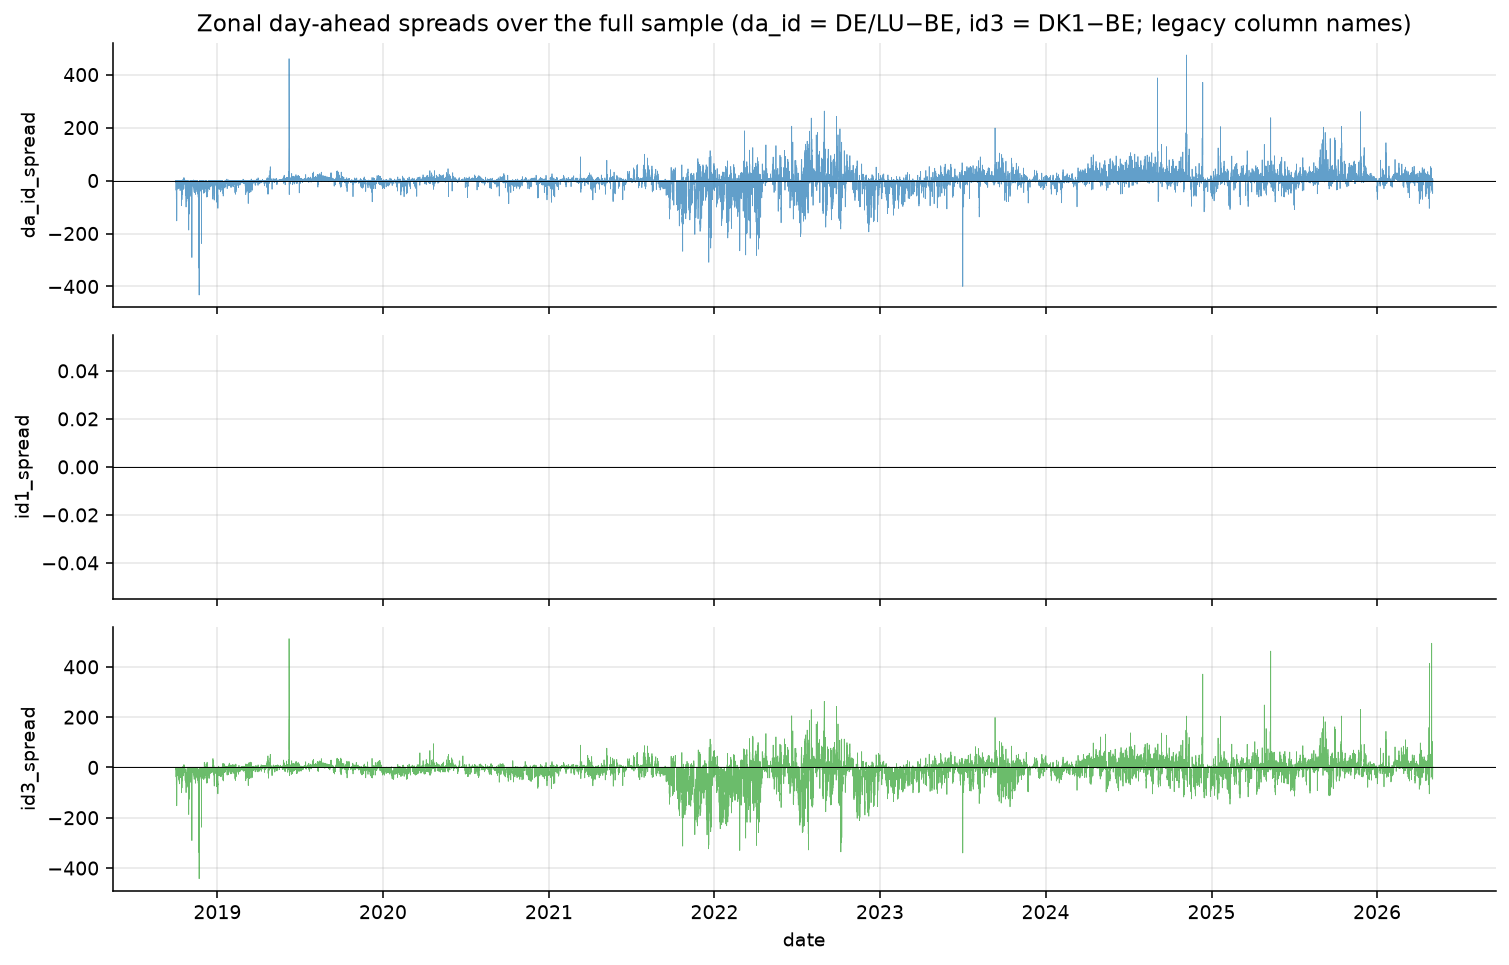

In [3]:
display(Image(str(FIG / 'q2_spread_timeseries.png')))

**Reading.** Mean-reverting around zero with stable variance is the coupling
story: spreads open on congestion and close again. Drift, or fat tails that
fail to close, would be the warning sign.


## 2.  Cointegration tests

In [4]:
df = pd.read_csv(TAB / 'q2_cointegration_summary.csv', index_col=0)
display(df)

,n_recent_daily,n_full_hourly,ADF_auction_p,ADF_cont_p,EG_t,EG_p,Joh_rank,Joh_beta,VECM_alpha,VECM_beta,halflife_h
ID3,1096,26281,0.000038,0.001401,-5.119455,9.870043e-05,2,"[np.complex128(1+0j), np.complex128(-0.6933541...","[np.float64(-0.7138411789620304), np.float64(-...","[np.float64(1.0), np.float64(-0.69335413778528...",5.534644
DA,1096,26281,0.000420,0.001401,-7.071174,5.803965e-09,2,"[np.complex128(1+0j), np.complex128(-0.7897417...","[np.float64(-0.964604463744961), np.float64(-0...","[np.float64(1.0), np.float64(-0.78974172467680...",3.492021


In [5]:
import pandas as pd

ct = SUMMARY['q2_cointegration']
rows = []
for label, d in ct.items():
    n = d.get('n_full_hourly', d.get('n', d.get('n_recent_daily', 0)))
    rows.append({
        'pair': f'{label} vs Cont',
        'n_hourly': d.get('n_full_hourly', n),
        'n_daily_for_tests': d.get('n_recent_daily', 'n/a'),
        'EG_t': round(d['EG_t'], 2),
        'EG_p': float(f"{d['EG_p']:.2e}"),
        'Joh_rank': d['Joh_rank'],
        'VECM_alpha_auction': round(d['VECM_alpha'][0], 3) if d.get('VECM_alpha') else None,
        'VECM_alpha_cont':    round(d['VECM_alpha'][1], 3) if d.get('VECM_alpha') else None,
        'half_life_h': round(d['halflife_h'], 2) if d.get('halflife_h') is not None else None,
    })
display(pd.DataFrame(rows))

,pair,n_hourly,n_daily_for_tests,EG_t,EG_p,Joh_rank,VECM_alpha_auction,VECM_alpha_cont,half_life_h
0,ID3 vs Cont,26281,1096,-5.12,9.870000e-05,2,-0.714,-0.256,5.53
1,DA vs Cont,26281,1096,-7.07,5.800000e-09,2,-0.965,-0.548,3.49


**Reading the VECM alpha.** Both legs clear simultaneously in the single
coupled auction, so there is no venue sequencing here and no price-discovery
question. The alpha asymmetry is descriptive: it says which zonal price does
more of the closing when a spread opens. The tests run on daily-resampled data,
so the alphas are per day. Note the Johansen rank of 2: in a bivariate system
that means both series are stationary on this window, so the spread tests
measure mean reversion rather than cointegration.


## 3.  Regime-conditional spread variance

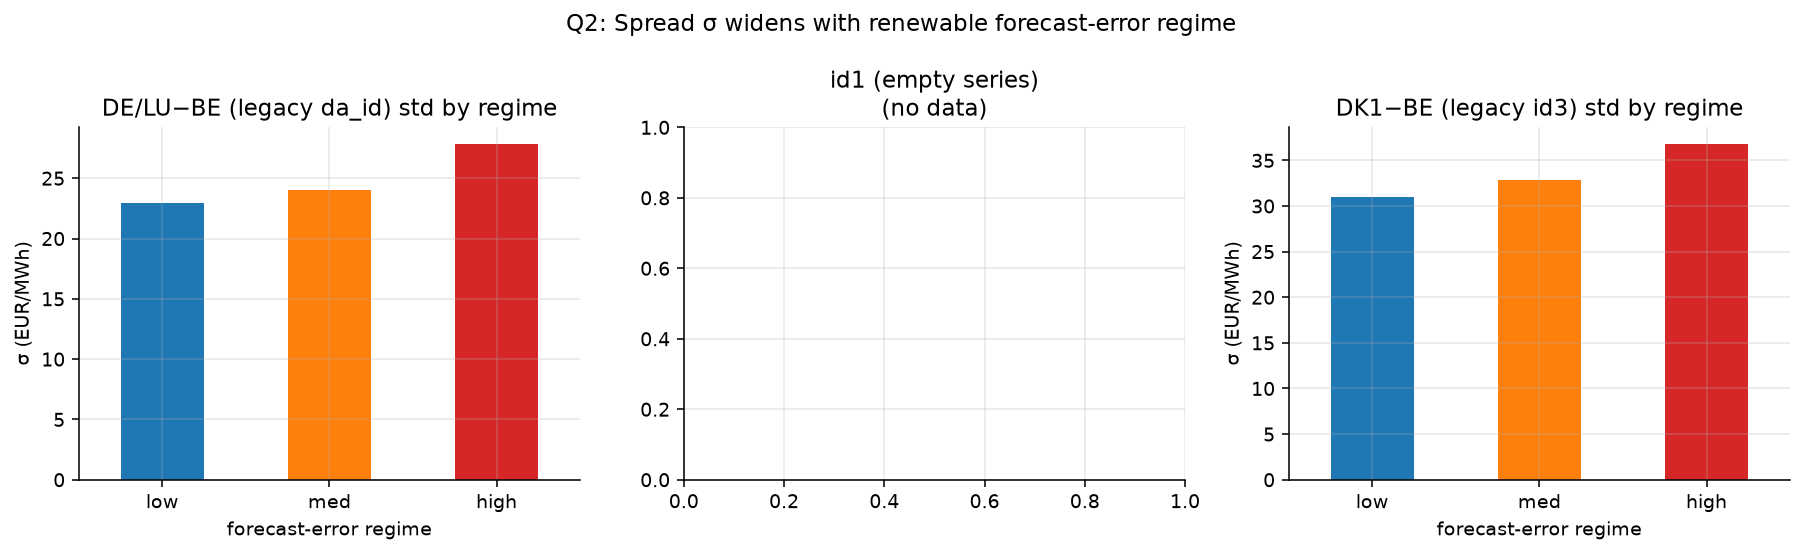

In [6]:
display(Image(str(FIG / 'q2_regime_variance.png')))

In [7]:
rv = SUMMARY['q2_regime_variance']
for spread_name, table in rv.items():
    display(Markdown(f'**{spread_name}**'))
    display(pd.DataFrame(table))

**da_id_spread**

,var,std,mean,count
0,527.856112,22.975119,0.839607,22101
1,577.808882,24.037656,-1.070371,22153
2,774.352098,27.827183,-3.600865,22272


**id3_spread**

,var,std,mean,count
0,962.496919,31.024134,-6.404240,22101
1,1079.224391,32.851551,-8.953661,22153
2,1352.886658,36.781608,-10.203060,22272


**Reading.** A monotone increase in sigma from low to high forecast-error
regime says congestion widens exactly when German renewable surprises are
large. The high-to-low ratio is the summary number.


## 4.  Time-stability of mean-reversion speed

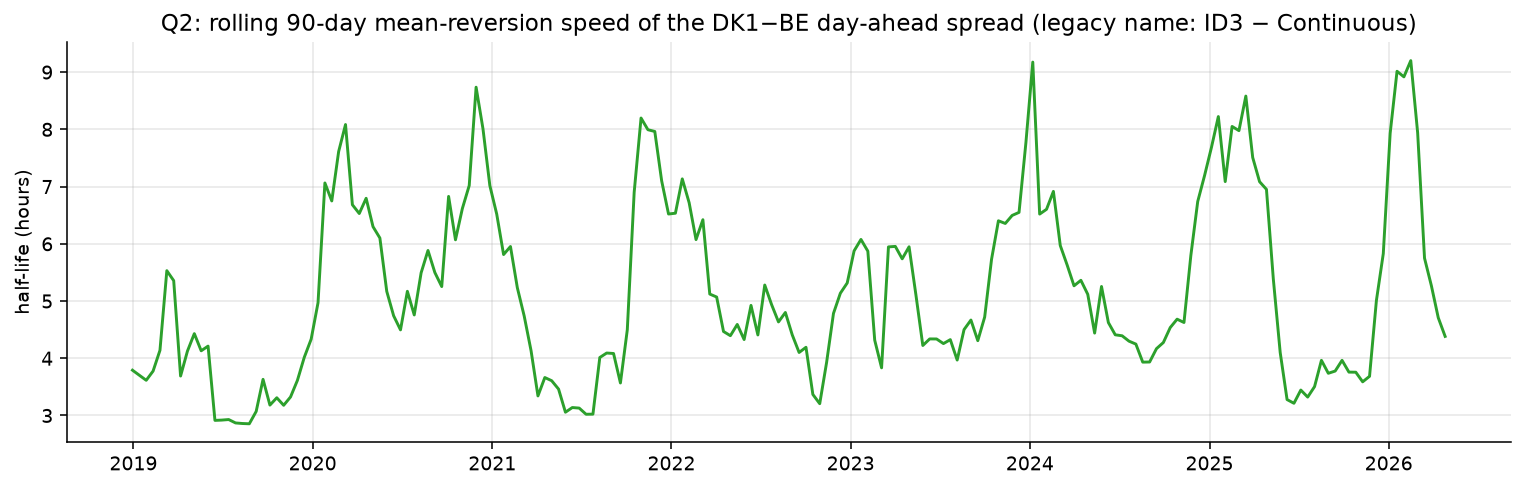

In [8]:
display(Image(str(FIG / 'q2_rolling_halflife.png')))

Rolling 90-day half-life of the DK1 minus Belgium spread. A stable line over a
multi-year sample means congestion episodes stay transient throughout; no
secular trend in either direction.


## 5.  Conclusions for Q2

In [9]:
ct = SUMMARY['q2_cointegration']
rv = SUMMARY['q2_regime_variance']

# Pick the pair with the cleanest evidence for the headline numbers
best = None
for label, d in ct.items():
    if d['Joh_rank'] >= 1 and d.get('halflife_h') is not None and pd.notna(d['halflife_h']):
        best = (label, d)
        break

def var_ratio(table):
    if not table or 'std' not in table:
        return None
    stds = table['std']
    keys = sorted(stds.keys(), key=lambda k: float(k))
    return float(stds[keys[-1]]) / float(stds[keys[0]]) if len(keys) >= 3 else None

ratios = {k: var_ratio(v) for k, v in rv.items() if v}

if best is None:
    display(Markdown('No pair with a finite half-life; see the table above.'))
else:
    label, d = best
    n_h = d.get('n_full_hourly', d.get('n', '?'))
    n_d = d.get('n_recent_daily', '?')
    # Johansen eigenvectors can serialise as complex strings like '(-0.69+0j)'
    jb = complex(str((d.get('Joh_beta') or [float('nan')] * 2)[1])).real
    a = d.get('VECM_alpha') or [None, None]
    display(Markdown(
f"""
**Q2, in short.**

1. **Strong mean reversion.** Pair **{label}** (legacy column naming; hourly
   n = {n_h:,}, formal tests on a {n_d:,}-day daily subsample).
   Engle-Granger t = **{d['EG_t']:.2f}**, p = **{d['EG_p']:.2e}**. Johansen
   rank = **{d['Joh_rank']}**; rank 2 in a bivariate system means both legs
   are stationary on this window, so this is mean reversion, not
   cointegration.
2. **Spread half-life on the full hourly sample = {d['halflife_h']:.2f}h**
   (closed-form AR(1), unit beta imposed). Johansen's beta is
   **{jb:.3f}** rather than -1, so the fully
   flexible half-life would be slightly shorter.
3. **Adjustment speeds (per day)**: alpha = **{a[0]:.3f}** and **{a[1]:.3f}**.
   Both negative, stable convergence; the first leg's magnitude is
   {abs(a[0])/abs(a[1]) if a[0] and a[1] else float('nan'):.1f}x the Belgian
   side, so the DE or DK1 price does most of the closing.
4. **Regime-conditional sigma ratio** (high vs low forecast error):
   {', '.join(f'{k} = **{v:.2f}x**' for k, v in ratios.items() if v is not None)}.
   Congestion widens when German renewable surprises are large.
"""
))



**Q2, in short.**

1. **Strong mean reversion.** Pair **ID3** (legacy column naming; hourly
   n = 26,281, formal tests on a 1,096-day daily subsample).
   Engle-Granger t = **-5.12**, p = **9.87e-05**. Johansen
   rank = **2**; rank 2 in a bivariate system means both legs
   are stationary on this window, so this is mean reversion, not
   cointegration.
2. **Spread half-life on the full hourly sample = 5.53h**
   (closed-form AR(1), unit beta imposed). Johansen's beta is
   **-0.693** rather than -1, so the fully
   flexible half-life would be slightly shorter.
3. **Adjustment speeds (per day)**: alpha = **-0.714** and **-0.256**.
   Both negative, stable convergence; the first leg's magnitude is
   2.8x the Belgian
   side, so the DE or DK1 price does most of the closing.
4. **Regime-conditional sigma ratio** (high vs low forecast error):
   da_id_spread = **1.21x**, id3_spread = **1.19x**.
   Congestion widens when German renewable surprises are large.
